# 📘 Module 42 — Deep Learning Debugging
## Part 3: Training Problems — Notes

These are **revision notes for the exact Training Problems section**: learning rate, model learning failure, overfitting, and underfitting. syllabus

---

# 1️⃣ Learning Rate Too High 🚀💥



### Definition

A learning rate that is too high causes **excessively large parameter updates**.

```text
θnew = θold − learning_rate × gradient
```

### Symptoms

- Loss oscillates
- Loss increases
- Training becomes unstable
- May produce `NaN` / `Inf`
- Optimizer overshoots the minimum

### Example

```text
2.1 → 5.7 → 1.8 → 8.9 → NaN
```

### 🔍 Debug

Check whether reducing the learning rate makes the loss curve stable.

---

# 2️⃣ Learning Rate Too Low 🐌



### Definition

A learning rate that is too low causes **very small parameter updates**.

### Symptoms

- Loss decreases extremely slowly
- Training takes too long
- Model appears almost stuck
- Parameters change very little

Example:

```text
2.50 → 2.48 → 2.46 → 2.45 → 2.44
```

The important distinction:

> **The model may still be learning — just too slowly.**

---

# ⚖️ Learning Rate Comparison

| LR | Behavior |
|---|---|
| 🔵 Too low | Very slow convergence |
| 🟢 Appropriate | Stable learning |
| 🔴 Too high | Oscillation / divergence |

```text
Too Low       Good         Too High
🐌            ✅           💥
─────────────►─────────────►
slow          stable       unstable
```

---

# 3️⃣ Model Not Learning 😵



### Definition

The model's performance does not improve meaningfully during training.

Example:

```text
Epoch 1 → 2.31
Epoch 2 → 2.30
Epoch 3 → 2.30
Epoch 4 → 2.30
Epoch 5 → 2.30
```
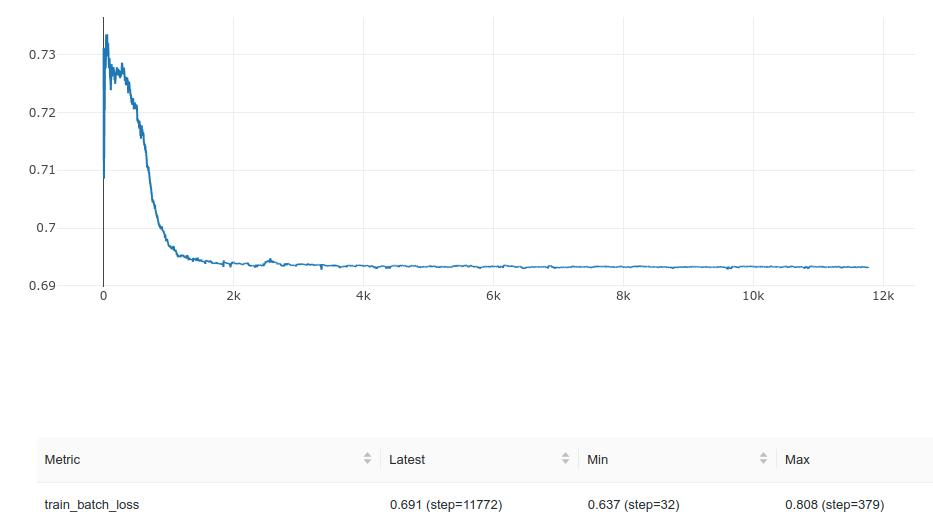
### 🔍 Possible causes

Don't immediately blame the learning rate.

Check:

```text
Model not learning
       │
       ├── Learning rate?
       ├── Loss function?
       ├── Activation?
       ├── Labels?
       ├── Normalization?
       ├── Gradients?
       └── Architecture?
```

### 🧠 Key principle

> **Training failure can originate from data, model configuration, optimization, or gradients.**

This connects the current section to the **Data Problems** and **Model Problems** already covered.

---

# 4️⃣ Overfitting 🧠💀



### Definition

The model performs extremely well on the **training data** but poorly on **unseen/validation data**.

### Typical pattern

```text
Training performance   ↑↑↑
Validation performance ↓
```

### Example

| Epoch | Train Accuracy | Validation Accuracy |
|---:|---:|---:|
| 10 | 85% | 82% |
| 20 | 93% | 88% |
| 30 | 97% | 87% |
| 40 | 99% | 83% |
| 50 | 100% | 78% |

🚨 The model is becoming better at training data while becoming worse at generalization.

### Common causes

- Model too complex
- Insufficient/diversity-limited data
- Training too long
- Insufficient regularization

---

# 5️⃣ Underfitting 📉



### Definition

The model **cannot learn the training data sufficiently well**.

```text
Training performance   ❌
Validation performance ❌
```

### Example

| Epoch | Train Accuracy | Validation Accuracy |
|---:|---:|---:|
| 10 | 55% | 52% |
| 20 | 58% | 55% |
| 30 | 59% | 56% |
| 40 | 60% | 56% |

Both training and validation performance remain poor.

### Possible causes

- Model too simple
- Insufficient training
- Excessive regularization
- Inadequate data representation
- Optimization/training problems

---

# 🆚 Overfitting vs Underfitting



| | Underfitting | Overfitting |
|---|---|---|
| Training performance | ❌ Poor | ✅ Very good |
| Validation performance | ❌ Poor | ❌ Poor |
| Main problem | Doesn't learn enough | Doesn't generalize |
| Typical behavior | Too simple / insufficiently trained | Memorizes training data |

### 🧠 Easy memory trick

> **Underfitting:** “I can't learn the training data.”  
> **Overfitting:** “I memorized the training data, but I can't generalize.”

---

# 🔥 Training Debugging Flow



```text
                 TRAIN MODEL
                     │
                     ↓
              Is loss improving?
                /          \
              NO            YES
              │              │
              ↓              ↓
        Check training    Compare Train
        configuration      vs Validation
              │              │
      ┌───────┴───────┐   ┌─┴──────────┐
      ↓       ↓       ↓   ↓            ↓
     LR     Loss   Gradients
                         │
                   Train + Val poor
                         ↓
                    UNDERFITTING

                   Train good
                   Val becomes poor
                         ↓
                    OVERFITTING
```

---

# 🧪 Quick Diagnostic Table

| Observation | Likely issue |
|---|---|
| Loss jumps wildly | LR too high / instability |
| Loss becomes `NaN` | LR too high / exploding gradients / numerical instability |
| Loss barely changes | LR too low / model not learning |
| Train ❌ + Validation ❌ | Underfitting / training problem |
| Train ✅ + Validation ❌ | Overfitting |
| Train and validation both improve | Healthy learning ✅ |

---

# 🧠 Golden Debugging Rule

Don't randomly change hyperparameters.

Instead:

```text
OBSERVE
   ↓
IDENTIFY PATTERN
   ↓
FORM HYPOTHESIS
   ↓
CHANGE ONE THING
   ↓
TRAIN AGAIN
   ↓
COMPARE
```

That is the core mindset of **deep-learning debugging**. 🔥

---

## 📌 One-Minute Revision

```text
LR TOO HIGH
→ Huge updates
→ Oscillation / divergence
→ NaN possible

LR TOO LOW
→ Tiny updates
→ Very slow convergence

MODEL NOT LEARNING
→ Loss/performance barely improves
→ Investigate LR, loss, activation,
  data, gradients, architecture

OVERFITTING
→ Training performance ↑
→ Validation performance ↓
→ Poor generalization

UNDERFITTING
→ Training performance ↓
→ Validation performance ↓
→ Model cannot learn sufficiently
```

---